## Project Title: Stroke Risk Prediction Using Machine Learning

### Source of Data: Kaggle


#### Background of Stroke

Stroke is a serious medical condition that occurs when the blood supply to part of the brain is interrupted or reduced, preventing brain tissue from receiving oxygen and nutrients. Within minutes, brain cells begin to die.
There are two major types of stroke:
a. Ischemic stroke – caused by blockage of blood vessels (most common)
b. Hemorrhagic stroke – caused by bleeding in the brain

Stroke is one of the leading causes of:
- Death worldwide
- Long-term disability
- Cognitive impairment

Risk factors include:
- Hypertension
- Heart disease
- Diabetes
- Smoking
- Obesity
- Sedentary lifestyle


#### Importance of Stroke Prediction

Predicting stroke risk is critical because prevention is more effective than treatment.
Early detection allows lifestyle modification and medical intervention.
Stroke treatment and rehabilitation are expensive. Predictive systems help allocate resources efficiently. A machine learning model can assist doctors in identifying high-risk patients early. Timely risk assessment reduces disability and death rates.


#### Project Objective

The objective of this project is to develop a machine learning classification model that predicts whether a patient is at risk of having a stroke based on demographic, medical, and lifestyle features.

The model will:
- Analyze patient data
- Identify patterns associated with stroke occurrence
- Predict stroke risk (Yes/No)
- Help healthcare providers make data-driven decisions

#### Define Target Variable

The target variable in this project is STROKE. It is a binary classification variable.

1 = Patient has had a stroke

0 = Patient has not had a stroke

This makes the problem a Supervised Binary Classification Problem.

## Import libraries

In [37]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\USER\Downloads\archive (20).zip")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Basic Data Inspection

In [4]:
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Data Cleaning

In [7]:
df = df.drop('id', axis=1)

## Handle Missing Values

In [8]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

## Encoding Categorical Variables

In [9]:
le = LabelEncoder()

categorical_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Exploratory Data Analysis (EDA)


#### BMI Distribution

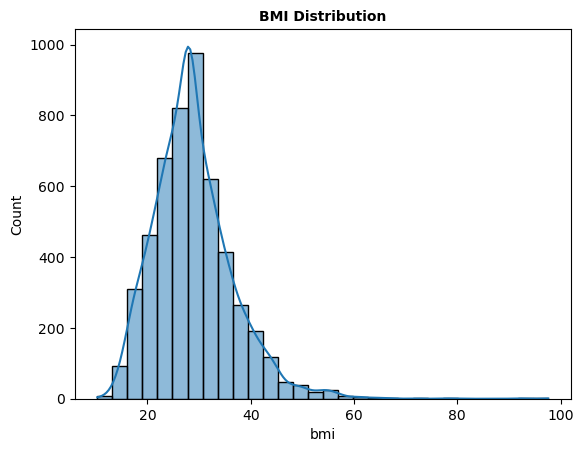

In [10]:
sns.histplot(df["bmi"], bins=30, kde=True)
plt.title("BMI Distribution",fontsize=10, fontweight= "bold")
plt.show()

##### This indicates that bmi(obesity) plays a role in stroke patients

#### Stroke Distribution

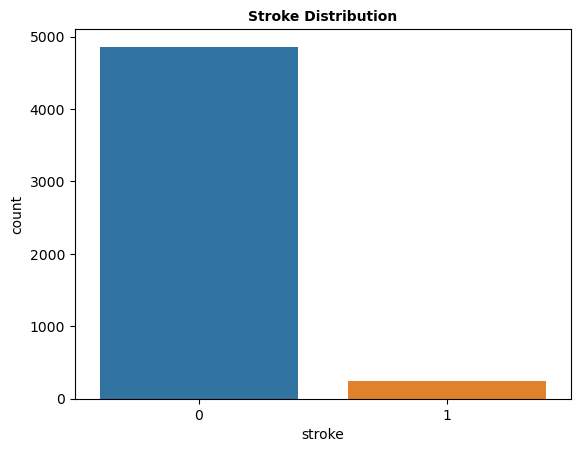

In [11]:
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution", fontsize=10, fontweight= "bold")
plt.show()

##### The dataset is highly imbalanced. No Stroke (0) ≈ 4861, Stroke (1) ≈ 249

#### Age vs Stroke

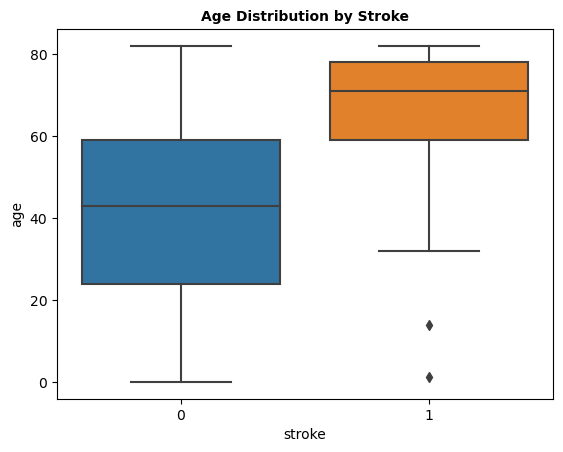

In [12]:
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age Distribution by Stroke", fontsize=10, fontweight= "bold")
plt.show()

##### The above visual clearly shows that older people are more likely to experience stroke

#### Stroke By Hypertension

Text(0.5, 1.0, 'Stroke by Hypertension')

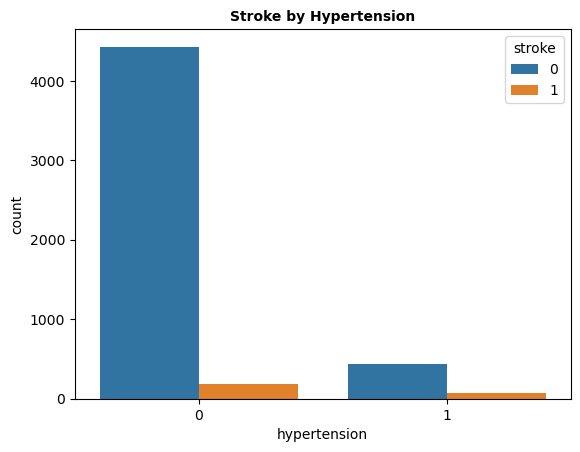

In [13]:
sns.countplot(x="hypertension", hue="stroke", data=df)
plt.title("Stroke by Hypertension", fontsize=10, fontweight= "bold")

##### This indicates that patients with hypertension have higher stroke risk

#### Correlation Heatmap

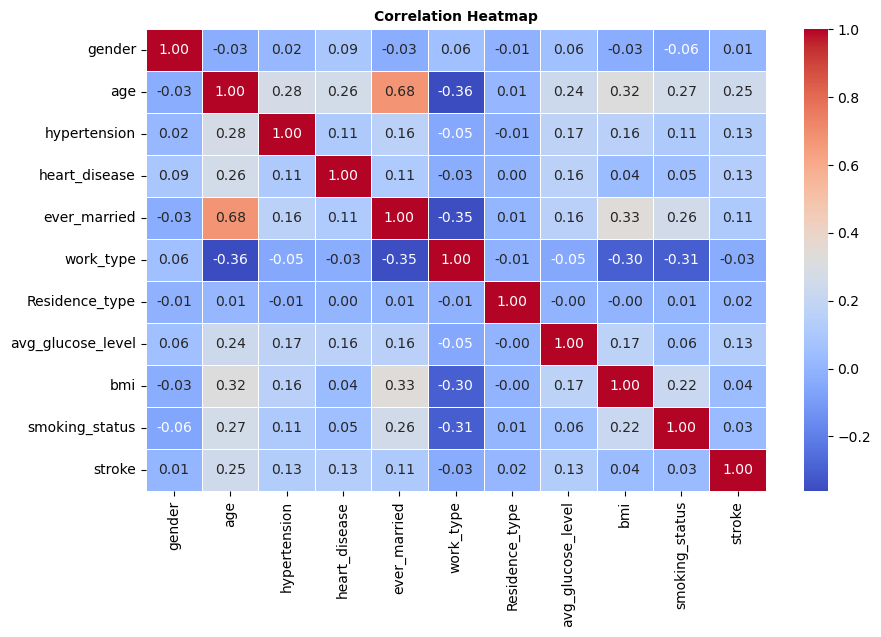

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)


plt.title("Correlation Heatmap",  fontsize=10, fontweight= "bold")
plt.show()

#### Only Correlation With Stroke

Text(0.5, 1.0, 'Correlation with Stroke')

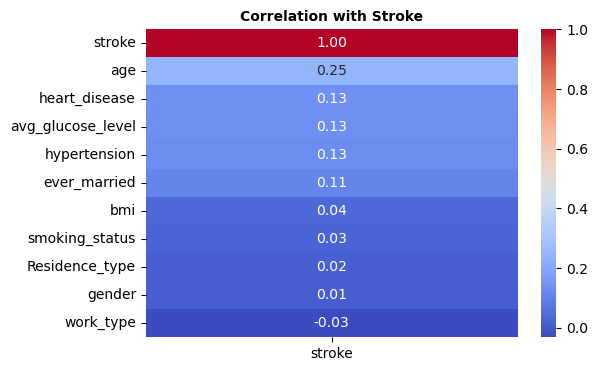

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr()[["stroke"]].sort_values(by="stroke", ascending=False), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation with Stroke",  fontsize=10, fontweight= "bold")

##### Age, hypertension, heart disease shows positive correlation with stroke
-Stroke risk increases with age

-Hypertension and heart disease increase stroke risk

-Glucose level influence stroke occurrence

## Feature Selection

In [16]:
X = df.drop('stroke', axis=1)
y = df['stroke']

## Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

## Handle Imbalanced Data Using SMOTE

In [18]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [19]:
y_train_sm.value_counts()     #now both classes become balanced.

0    3889
1    3889
Name: stroke, dtype: int64

## Feature Scaling

In [20]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

## Train Machine Learning Models

#### 1 Logistic Regression

In [21]:
log_model = LogisticRegression()

log_model.fit(X_train_sm, y_train_sm)

log_pred = log_model.predict(X_test)

#### 2 Decision Tree

In [22]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_sm, y_train_sm)

dt_pred = dt_model.predict(X_test)

#### 3 Random Forest

In [23]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)

#### 4 KNN

In [24]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_sm, y_train_sm)

knn_pred = knn_model.predict(X_test)

#### 5 XGBoost

In [25]:
xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred = xgb_model.predict(X_test)

## Model Evaluation

#### Logistic Regression

In [26]:
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))

[[766 206]
 [ 14  36]]
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       972
           1       0.15      0.72      0.25        50

    accuracy                           0.78      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.94      0.78      0.84      1022



In [27]:
roc_auc_score(y_test, log_pred)

0.7540329218106996

#### Decision Tree

In [28]:
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

[[873  99]
 [ 40  10]]
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       972
           1       0.09      0.20      0.13        50

    accuracy                           0.86      1022
   macro avg       0.52      0.55      0.53      1022
weighted avg       0.91      0.86      0.89      1022



In [29]:
roc_auc_score(y_test, dt_pred)

0.549074074074074

#### Random Forest

In [30]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[913  59]
 [ 41   9]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.13      0.18      0.15        50

    accuracy                           0.90      1022
   macro avg       0.54      0.56      0.55      1022
weighted avg       0.92      0.90      0.91      1022



In [31]:
roc_auc_score(y_test, rf_pred)

0.5596502057613169

#### KNN

In [32]:
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

[[802 170]
 [ 32  18]]
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       972
           1       0.10      0.36      0.15        50

    accuracy                           0.80      1022
   macro avg       0.53      0.59      0.52      1022
weighted avg       0.92      0.80      0.85      1022



In [33]:
roc_auc_score(y_test, knn_pred)

0.592551440329218

#### XGBoost

In [34]:
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

[[917  55]
 [ 40  10]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.15      0.20      0.17        50

    accuracy                           0.91      1022
   macro avg       0.56      0.57      0.56      1022
weighted avg       0.92      0.91      0.91      1022



In [35]:
roc_auc_score(y_test, xgb_pred)

0.5717078189300411

In [69]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    precision, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_curve, precision)

    cm = confusion_matrix(y_test, y_pred)

    return recall, f1, roc, pr_auc, cm

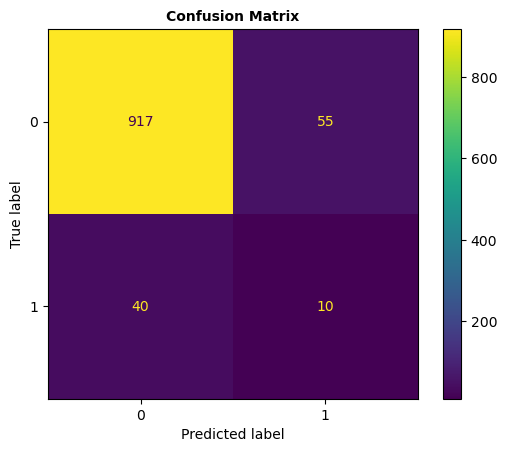

In [73]:
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("Confusion Matrix", fontsize=10, fontweight= "bold")
plt.show()

## Model Comparison 

In [39]:
results = []

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "KNN": knn_model,
    "Decition Tree": dt_model
}

for name, model in models.items():
    recall, f1, roc, pr_auc, cm = evaluate_model(model, X_test, y_test)

    results.append({
        "Model": name,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc,
        "PR-AUC": pr_auc
    })

import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
results_df

,Model,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.72,0.246575,0.786646,0.161608
3,KNN,0.36,0.151261,0.642850,0.114813
2,XGBoost,0.20,0.173913,0.777058,0.118573
4,Decition Tree,0.20,0.125786,0.549074,0.165441
1,Random Forest,0.18,0.152542,0.779270,0.119614


In [41]:
best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


#### My Best Model is Logistic Regression.

- Recall = 0.72 (Highest by far)

- F1 Score = 0.246 (also highest)

- ROC-AUC = 0.79 (good)

- PR-AUC = reasonable


y_pred_final = (y_prob >= best_threshold).astype(int)

print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1:", f1_score(y_test, y_pred_final))

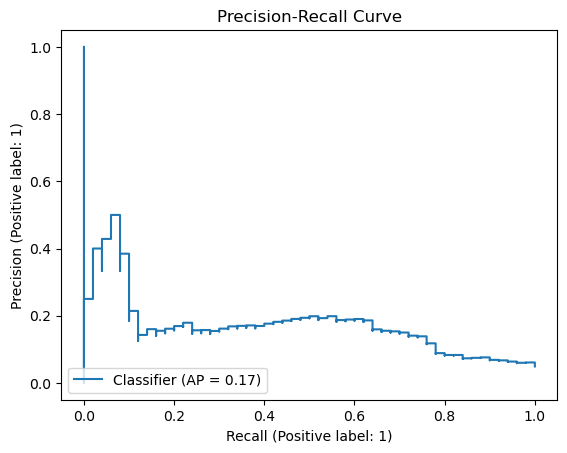

In [46]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision-Recall Curve")
plt.show()

## Feature Importance

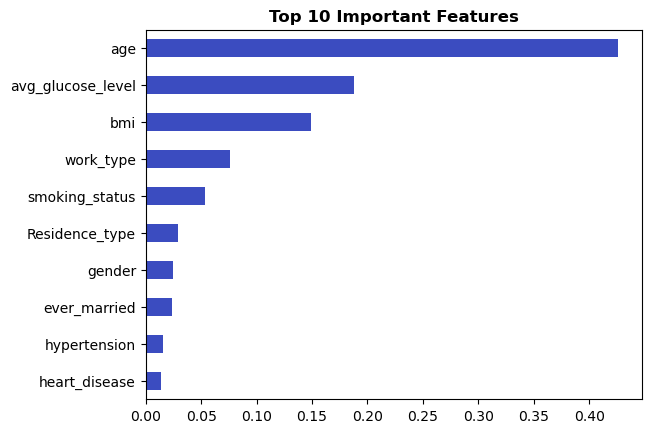

In [49]:
importance = rf_model.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values().plot(kind= "barh", cmap="coolwarm")
plt.title("Top 10 Important Features", fontsize=12, fontweight="bold")
plt.show()


## Class Weight

In [66]:
log_model = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Hyperparameter Tuning

#### Tune Logistic Regression

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid,
    scoring="recall",   
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_

print("Best Parameters:", grid_log.best_params_)

Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


In [64]:
y_pred_final = (y_prob >= best_threshold).astype(int)

print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1:", f1_score(y_test, y_pred_final))

Final Recall: 0.2
Final F1: 0.12578616352201258


#### Tune Decision Tree

In [ ]:
dt_params = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=5,
    scoring='roc_auc'
)

grid_dt.fit(X_train_sm, y_train_sm)

best_dt = grid_dt.best_estimator_

#### Tune Random Forest

In [ ]:
rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train_sm, y_train_sm)

best_rf = grid_rf.best_estimator_

#### Tune KNN

In [ ]:
knn_params = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='roc_auc'
)

grid_knn.fit(X_train_sm, y_train_sm)

best_knn = grid_knn.best_estimator_

#### Tune XGBoost

In [ ]:
xgb_params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.2],
    'subsample':[0.8,1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train_sm, y_train_sm)

best_xgb = grid_xgb.best_estimator_

In [68]:
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0.5
best_recall = 0

y_prob = best_model.predict_proba(X_test)[:, 1]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)

    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.1


## Evaluate Tuned Models

In [55]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import recall_score, f1_score

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Recall: 0.2
F1 Score: 0.17391304347826086


In [56]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import recall_score, f1_score

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Recall: 0.72
F1 Score: 0.24657534246575347


In [57]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import recall_score, f1_score

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Recall: 0.18
F1 Score: 0.15254237288135591


In [58]:
y_pred = knn_model.predict(X_test)
y_prob = knn_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import recall_score, f1_score

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Recall: 0.36
F1 Score: 0.15126050420168066


In [59]:
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import recall_score, f1_score

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Recall: 0.2
F1 Score: 0.12578616352201258


## Key Insights From Dataset

- Age is the strongest predictor: Stroke occurs mostly in older patients.

- Hypertension increases stroke risk: Patients with hypertension show significantly higher stroke probability.

- Heart disease is a major factor: Heart disease strongly correlates with stroke occurrence.

- High glucose level increases stroke risk:Patients with high blood glucose levels are more likely to experience stroke.

- Imbalanced dataset: Stroke cases represent less than 5% of data, which required SMOTE balancing.

#### Final Conclusion
- Logistic Regression outperformed more complex models in terms of Recall, which is critical in this healthcare problem. This suggests that the dataset has relatively simple decision boundaries, and complex models may not generalize well to the minority class.


- This project addresses the problem of late stroke detection by building a predictive model that identifies high-risk patients early. By prioritizing Recall, the model minimizes false negatives, ensuring that fewer stroke cases are missed. This can support clinicians in preventive care and reduce mortality rates. In simple terms, this  project helps save lives by enabling early detection of stroke risk using data.


